# **Projet AARN : Deep Learning for Crop Classification Using Multi-Source Satellite Data**
# **Part 3: HYBRID CROPNET**
----------------------------------------------
**Prepared by BOUSSELOUB Islem**

In [2]:
import os
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
data_path = os.path.join("drive", "MyDrive", "AARN_Projet", "AdditionalData")
model_path = os.path.join("drive", "MyDrive", "AARN_Projet", "Models")
os.makedirs(model_path, exist_ok=True)


Mounted at /content/drive


# **Data loading et preperation**

In [3]:

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

DATA_PATH = '/content/drive/MyDrive/AARN_Projet/AdditionalData'
SAVE_DIR  = '/content/drive/MyDrive/AARN_Projet/Models'


# Hyperparamètres
T          = 36    #
C_S2       = 10    # bandes Sentinel-2
STATIC_DIM = 5     # features statiques (région)
D_MODEL    = 64
N_STAGES   = 4
N_HEAD     = 8
BATCH_SIZE = 64
EPOCHS     = 80
LR         = 1e-3


# Classes CDL
CLASS_NAMES = {
    1: 'Corn', 2: 'Cotton', 3: 'Rice', 5: 'Soybeans',
    61: 'Fallow/Idle Cropland', 66: 'Cherries', 69: 'Grapes',
    71: 'Other Tree Crops', 72: 'Citrus', 74: 'Alfalfa',
    75: 'Almonds', 121: 'Developed/Open Space',
    204: 'Pistachios', 999: 'Others',
}

os.makedirs(SAVE_DIR, exist_ok=True)
print('Config OK ✓')

Config OK ✓


In [4]:
import os
import pandas as pd

cal1 = pd.read_csv(os.path.join(data_path, "california/region1/crops_CDL_CaliforniaRegion1.csv"))

# nouveaux
ark1 = pd.read_csv(os.path.join(data_path, "arkansas/region1/crops_CDL_ArkansasRegion1.csv"))
ark2 = pd.read_csv(os.path.join(data_path, "arkansas/region2/crops_CDL_ArkansasRegion2.csv"))
cal2 = pd.read_csv(os.path.join(data_path, "california/region2/crops_CDL_CaliforniaRegion2.csv"))



# nettoyage colonnes inutiles
def clean(df):
    return df.drop(columns=['.geo', 'system:index'], errors='ignore')

cal1 = clean(cal1)
ark1 = clean(ark1)
ark2 = clean(ark2)
cal2 = clean(cal2)

# ajouter colonne région
cal1['region'] = 'california1'
cal2['region'] = 'california2'
ark1['region'] = 'arkansas1'
ark2['region'] = 'arkansas2'

# fusion
dataset = pd.concat([cal1, ark1, ark2, cal2], ignore_index=True)

print(dataset.shape)
dataset.head()

(16381, 362)


,0_B11,0_B12,0_B2,0_B3,0_B4,0_B5,0_B6,0_B7,0_B8,0_B8A,...,9_B2,9_B3,9_B4,9_B5,9_B6,9_B7,9_B8,9_B8A,cropland,region
0,0.2174,0.1754,0.0446,0.0526,0.0712,0.0861,0.1122,0.1247,0.1502,0.1514,...,0.04830,0.07935,0.09520,0.12490,0.20420,0.22890,0.2480,0.24875,72,california1
1,0.2371,0.2155,0.0426,0.0512,0.0696,0.0866,0.0913,0.1085,0.1202,0.1306,...,0.06450,0.08805,0.10680,0.14150,0.20065,0.21780,0.2378,0.24690,69,california1
2,0.2176,0.1655,0.0582,0.0700,0.0920,0.1263,0.1517,0.1721,0.1824,0.2025,...,0.05375,0.07860,0.09935,0.13720,0.18125,0.19655,0.2122,0.21885,71,california1
3,0.2439,0.2090,0.0522,0.0637,0.0780,0.1377,0.1420,0.1610,0.1570,0.1704,...,0.04855,0.07910,0.08895,0.16230,0.22490,0.25080,0.2700,0.26330,121,california1
4,0.1817,0.1397,0.0391,0.0526,0.0679,0.0957,0.1224,0.1407,0.1622,0.1659,...,0.04570,0.07110,0.08980,0.12605,0.17075,0.18405,0.2061,0.20685,71,california1


In [5]:
# merge small classes into others
threshold = 0.02 * len(dataset)
class_counts = dataset['cropland'].value_counts()
small_classes = class_counts[class_counts < threshold].index

dataset['cropland'] = dataset['cropland'].apply(
    lambda x: 999 if x in small_classes else x
)

# Match cdl's codes with them class names
named_counts = dataset['cropland'].value_counts().rename(index=CLASS_NAMES)
print(named_counts)

# supprimer 5000 samples de la classe 3 pour l'equilibre
# merge small classes into others
threshold = 0.02 * len(dataset)
class_counts = dataset['cropland'].value_counts()

small_classes = class_counts[class_counts < threshold].index

dataset['cropland'] = dataset['cropland'].apply(
    lambda x: 999 if x in small_classes else x
)

# Match cdl's codes with them classnaems
named_counts = dataset['cropland'].value_counts().rename(index=CLASS_NAMES)
print(named_counts)


# supprimer 5000 samples de la classe 3 pour l'equilibre
class_3 = dataset[dataset['cropland'] == 3]
to_remove = class_3.sample(n=5000, random_state=42)
dataset = dataset.drop(to_remove.index)


named_counts = dataset['cropland'].value_counts().rename(index=CLASS_NAMES)
print("After removing the rice samples : ", named_counts)

cropland
Rice        8667
Soybeans    2915
Corn        2403
Others      1078
Cotton       712
Grapes       606
Name: count, dtype: int64
cropland
Rice        8667
Soybeans    2915
Corn        2403
Others      1078
Cotton       712
Grapes       606
Name: count, dtype: int64
After removing the rice samples :  cropland
Rice        3667
Soybeans    2915
Corn        2403
Others      1078
Cotton       712
Grapes       606
Name: count, dtype: int64


# **X and Y**
- X = données (features)
- y = labels (types de cultures)

In [6]:
X = dataset.drop(columns=['cropland', 'region']).values
y = dataset['cropland'].values

print(X.shape)

# Transformer les données en forme (36, 10)
X = X.reshape(len(X), 36, 10)
print("X shape:", X.shape)

# Transformer les donnes en nombres
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

num_classes = len(label_encoder.classes_)
print("Classes:", num_classes)

(11381, 360)
X shape: (11381, 36, 10)
Classes: 6


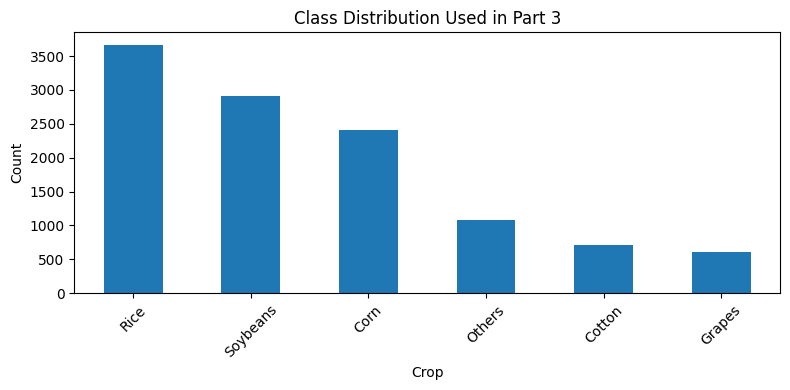

In [7]:
import matplotlib.pyplot as plt
# Quick visualization of the final class distribution
named_counts = dataset["cropland"].value_counts().rename(index=CLASS_NAMES)

plt.figure(figsize=(8, 4))
named_counts.plot(kind="bar", color="#1f77b4")
plt.title("Class Distribution Used in Part 3")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# **Train Test Split**


In [8]:
from sklearn.model_selection import train_test_split

def stratified_split(df, n_train=240, n_val=60):
    train_list, val_list, test_list = [], [], []
    for cls, group in df.groupby('cropland'):
        group = group.sample(frac=1, random_state=42).reset_index(drop=True)
        train_list.append(group.iloc[:n_train])
        val_list.append(group.iloc[n_train:n_train + n_val])
        test_list.append(group.iloc[n_train + n_val:])
    return pd.concat(train_list), pd.concat(val_list), pd.concat(test_list)

ark = dataset[dataset['region'].isin(['arkansas1', 'arkansas2'])]
cal = dataset[dataset['region'].isin(['california1', 'california2'])]

ark_train, ark_val, ark_test = stratified_split(ark)
cal_train, cal_val, cal_test = stratified_split(cal)

train_df = pd.concat([ark_train, cal_train])
val_df   = pd.concat([ark_val,   cal_val])
test_df  = pd.concat([ark_test,  cal_test])

feature_cols = [c for c in dataset.columns if '_B' in c]

X_train = train_df[feature_cols].values.reshape(-1, 36, 10)
X_val   = val_df[feature_cols].values.reshape(-1, 36, 10)
X_test  = test_df[feature_cols].values.reshape(-1, 36, 10)

y_train = label_encoder.fit_transform(train_df['cropland'].values)
y_val   = label_encoder.transform(val_df['cropland'].values)
y_test  = label_encoder.transform(test_df['cropland'].values)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (1916, 36, 10)
Val:   (420, 36, 10)
Test:  (9045, 36, 10)


# **Preprocessing HybridCropNet**

In [9]:
def normalize_temporal(X_tr, X_v, X_te):
    B, Ts, C = X_tr.shape
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_tr.reshape(-1, C)).reshape(B, Ts, C)
    Xv  = scaler.transform(X_v.reshape(-1, C)).reshape(X_v.shape[0], Ts, C)
    Xt  = scaler.transform(X_te.reshape(-1, C)).reshape(X_te.shape[0], Ts, C)
    return Xtr, Xv, Xt, scaler

# ✅ Utilise vos variables existantes X_train / X_val / X_test
X_train, X_val, X_test, scaler = normalize_temporal(X_train, X_val, X_test)
print('Normalisation OK ✓ — mean ~0:', X_train.mean().round(3),
      '| std ~1:', X_train.std().round(3))

# ── 5b. Masque temporel ────────────────────────────────────
def build_mask(X):
    invalid = np.all(X == 0, axis=-1) | np.any(np.isnan(X), axis=-1)
    return (~invalid).astype(np.float32)

mask_train = build_mask(X_train)
mask_val   = build_mask(X_val)
mask_test  = build_mask(X_test)
print(f'Masque train — % valide : {mask_train.mean()*100:.1f}%')

# ── 5c. Features statiques (région CDL) ────────────────────
def build_static_features(df, region_encoder=None):
    regions = df['region'].values
    if region_encoder is None:
        region_encoder = {r: i for i, r in
                          enumerate(sorted(set(regions)))}
    static = np.zeros((len(df), 5), dtype=np.float32)
    for i, r in enumerate(regions):
        idx = region_encoder.get(r, 0)
        if idx < 4: static[i, idx] = 1.0
        static[i, 4] = 1.0 if 'california' in r else 0.0
    return static, region_encoder

S_train, region_enc = build_static_features(train_df)
S_val,   _          = build_static_features(val_df,  region_enc)
S_test,  _          = build_static_features(test_df, region_enc)
print(f'Static features : {S_train.shape} ✓')

# ── 5d. Labels one-hot ─────────────────────────────────────
y_train_enc = label_encoder.transform(train_df['cropland'].values)
y_val_enc   = label_encoder.transform(val_df['cropland'].values)
y_test_enc  = label_encoder.transform(test_df['cropland'].values)

y_train_cat = keras.utils.to_categorical(y_train_enc, num_classes).astype(np.float32)
y_val_cat   = keras.utils.to_categorical(y_val_enc,   num_classes).astype(np.float32)

# ── 5e. Class weights (déséquilibre) ───────────────────────
cw = compute_class_weight('balanced',
                           classes=np.unique(y_train_enc),
                           y=y_train_enc)
class_weight_dict = dict(enumerate(cw))
print('Class weights OK ✓', class_weight_dict)

Normalisation OK ✓ — mean ~0: 0.0 | std ~1: 1.0
Masque train — % valide : 100.0%
Static features : (1916, 5) ✓
Class weights OK ✓ {0: np.float64(1.3305555555555555), 1: np.float64(1.3305555555555555), 2: np.float64(0.6652777777777777), 3: np.float64(1.3305555555555555), 4: np.float64(1.3305555555555555), 5: np.float64(0.6708683473389355)}


# **Architecture HybridCropNet**

In [10]:

class ChannelAttention(keras.layers.Layer):
    def __init__(self, reduction=8, **kwargs):
        super().__init__(**kwargs)
        self.reduction = reduction
    def build(self, input_shape):
        C = input_shape[-1]; mid = max(C // self.reduction, 1)
        self.avg_pool = keras.layers.GlobalAveragePooling1D()
        self.max_pool = keras.layers.GlobalMaxPooling1D()
        self.fc1 = keras.layers.Dense(mid, activation='relu', use_bias=False)
        self.fc2 = keras.layers.Dense(C, use_bias=False)
    def call(self, x):
        avg = self.fc2(self.fc1(self.avg_pool(x)))
        mx  = self.fc2(self.fc1(self.max_pool(x)))
        return x * tf.expand_dims(tf.sigmoid(avg + mx), 1)

class SpatialAttention(keras.layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.conv = keras.layers.Conv1D(1, kernel_size, padding='same',
                                        activation='sigmoid', use_bias=False)
    def call(self, x):
        feat = tf.concat([tf.reduce_mean(x, -1, keepdims=True),
                          tf.reduce_max(x,  -1, keepdims=True)], axis=-1)
        return x * self.conv(feat)

class CBAM(keras.layers.Layer):
    def __init__(self, reduction=8, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.ca = ChannelAttention(reduction)
        self.sa = SpatialAttention(kernel_size)
    def call(self, x):
        return self.sa(self.ca(x))

class ALPE(keras.layers.Layer):
    def __init__(self, d_model, max_len=36, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model; self.max_len = max_len
    def build(self, input_shape):
        self.conv = keras.layers.Conv1D(self.d_model, 3, padding='same', use_bias=False)
        self.cbam = CBAM()
    def call(self, x, mask):
        T_current = tf.shape(x)[1]          # ← AJOUT
        pos  = np.arange(self.max_len)[:, None]
        dims = np.arange(self.d_model)[None, :]
        pe   = np.where(dims % 2 == 0,
                        np.sin(pos / (10000 ** (dims / self.d_model))),
                        np.cos(pos / (10000 ** ((dims-1) / self.d_model)))).astype(np.float32)
        pe = tf.constant(pe)
        pe = pe[:T_current, :]
        pe = tf.tile(pe[None], [tf.shape(x)[0], 1, 1])
        mask_cropped = mask[:, :T_current]
        pe = pe * tf.cast(tf.expand_dims(mask_cropped, -1), tf.float32)
        return self.cbam(self.conv(pe))

class DropPath(keras.layers.Layer):
    def __init__(self, drop_prob=0.1, **kwargs):
        super().__init__(**kwargs); self.drop_prob = drop_prob
    def call(self, x, training=False):
        if not training or self.drop_prob == 0: return x
        keep  = 1.0 - self.drop_prob
        shape = (tf.shape(x)[0],) + (1,) * (len(x.shape) - 1)
        return x * tf.floor(tf.random.uniform(shape) + keep) / keep

class DSCNNBlock(keras.layers.Layer):
    def __init__(self, filters, kernel_size=3, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters; self.kernel_size = kernel_size
    def build(self, input_shape):
        self.dw   = keras.layers.DepthwiseConv1D(self.kernel_size, padding='same', use_bias=False)
        self.bn1  = keras.layers.BatchNormalization()
        self.pw   = keras.layers.Conv1D(self.filters, 1, use_bias=False)
        self.bn2  = keras.layers.BatchNormalization()
        self.cbam = CBAM()
        self.act  = keras.layers.Activation('gelu')
        self.drop = DropPath(0.1)
        self.proj = keras.layers.Conv1D(self.filters, 1, use_bias=False) \
                    if input_shape[-1] != self.filters else None
    def call(self, x, training=False):
        res = self.proj(x) if self.proj else x
        out = self.act(self.bn1(self.dw(x), training=training))
        out = self.bn2(self.pw(out), training=training)
        return self.act(self.drop(self.cbam(out), training=training) + res)

class TransformerBlock(keras.layers.Layer):
    def __init__(self, d_model, n_head, max_len=36, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model; self.n_head = n_head; self.max_len = max_len
    def build(self, input_shape):
        self.alpe  = ALPE(self.d_model, self.max_len)
        self.norm1 = keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = keras.layers.LayerNormalization(epsilon=1e-6)
        self.attn  = keras.layers.MultiHeadAttention(
            num_heads=self.n_head, key_dim=self.d_model // self.n_head, dropout=0.1)
        self.ffn   = keras.Sequential([
            keras.layers.Dense(self.d_model * 4, activation='gelu'),
            keras.layers.Dropout(0.1),
            keras.layers.Dense(self.d_model)
        ])
        self.drop1 = DropPath(0.1); self.drop2 = DropPath(0.1)
    def call(self, x, mask=None, training=False):
        if mask is not None:
            x = x + self.alpe(x, mask)
        xn = self.norm1(x)
        x  = x + self.drop1(self.attn(xn, xn, xn, training=training), training=training)
        x  = x + self.drop2(self.ffn(self.norm2(x), training=training), training=training)
        return x

class GatedCTFusion(keras.layers.Layer):
    def __init__(self, d_model, n_head, max_len=36, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model; self.n_head = n_head; self.max_len = max_len
    def build(self, input_shape):
        self.cnn  = DSCNNBlock(self.d_model)
        self.tran = TransformerBlock(self.d_model, self.n_head, self.max_len)
        self.gate = keras.layers.Dense(self.d_model, activation='sigmoid')
        self.proj = keras.layers.Dense(self.d_model, use_bias=False)
        self.norm = keras.layers.LayerNormalization(epsilon=1e-6)
    def call(self, x, mask=None, training=False):
        cnn_out = self.cnn(x, training=training)
        tr_out  = self.tran(x, mask, training=training)
        gate    = self.gate(x)
        return self.norm(self.proj(gate * cnn_out + (1 - gate) * tr_out))

class StaticEncoder(keras.layers.Layer):
    def __init__(self, out_dim=64, **kwargs):
        super().__init__(**kwargs); self.out_dim = out_dim
    def build(self, input_shape):
        self.fc1  = keras.layers.Dense(128, activation='gelu')
        self.bn1  = keras.layers.BatchNormalization()
        self.fc2  = keras.layers.Dense(self.out_dim, activation='gelu')
        self.bn2  = keras.layers.BatchNormalization()
        self.drop = keras.layers.Dropout(0.2)
    def call(self, x, training=False):
        return self.bn2(self.fc2(self.drop(
            self.bn1(self.fc1(x), training=training), training=training)),
            training=training)

class MultiScalePooling(keras.layers.Layer):
    def call(self, x):
        return tf.concat([tf.reduce_max(x, 1), tf.reduce_mean(x, 1), x[:, -1, :]], axis=-1)

# Model class
class HybridCropNet(keras.Model):
    def __init__(self, in_channels=10, static_dim=5, d_model=64,
                 n_stages=4, n_head=8, n_classes=5, max_len=36,
                 drop_rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.n_stages   = n_stages
        self.static_dim = static_dim
        self.input_proj = keras.Sequential([
            keras.layers.Dense(d_model, use_bias=False),
            keras.layers.LayerNormalization(epsilon=1e-6)
        ])
        self.stages = [
            GatedCTFusion(d_model, n_head, max(max_len // (2**min(i,2)), 4))
            for i in range(n_stages)
        ]
        self.temporal_downs = [
            keras.layers.Conv1D(d_model, 2, strides=2, padding='same')
            for _ in range(n_stages - 1)
        ]
        self.static_enc = StaticEncoder(out_dim=d_model) if static_dim > 0 else None
        if self.static_enc:
            self.cross_attn = keras.layers.MultiHeadAttention(num_heads=4, key_dim=d_model//4)
            self.cross_norm = keras.layers.LayerNormalization(epsilon=1e-6)
        self.ms_pool = MultiScalePooling()
        pool_dim = d_model * 3 + (d_model if static_dim > 0 else 0)
        self.head = keras.Sequential([
            keras.layers.Dense(256, activation='gelu'),
            keras.layers.Dropout(drop_rate),
            keras.layers.LayerNormalization(epsilon=1e-6),
            keras.layers.Dense(128, activation='gelu'),
            keras.layers.Dropout(drop_rate / 2),
            keras.layers.Dense(n_classes, activation='softmax')
        ])

    def call(self, inputs, training=False):
        if len(inputs) == 3:
            x_t, mask, x_s = inputs
        else:
            x_t, mask = inputs; x_s = None
        x = self.input_proj(x_t)
        for i, stage in enumerate(self.stages):
            x = stage(x, mask if x.shape[1] and x.shape[1] > 1 else None, training=training)
            if i < self.n_stages - 1:
                x = self.temporal_downs[i](x)
        if self.static_enc and x_s is not None:
            s   = tf.expand_dims(self.static_enc(x_s, training=training), 1)
            x   = self.cross_norm(x + self.cross_attn(x, s, s, training=training))
        pooled = self.ms_pool(x)
        if self.static_enc and x_s is not None:
            pooled = tf.concat([pooled, self.static_enc(x_s, training=training)], axis=-1)
        return self.head(pooled, training=training)

print('Architecture HybridCropNet définie ✓')

Architecture HybridCropNet définie ✓


# compilation

In [11]:

lr_schedule = keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=LR, first_decay_steps=1000, t_mul=2.0, m_mul=0.9
)
optimizer = keras.optimizers.AdamW(
    learning_rate=lr_schedule, weight_decay=1e-4, clipnorm=1.0
)

model = HybridCropNet(
    in_channels=C_S2, static_dim=STATIC_DIM, d_model=D_MODEL,
    n_stages=N_STAGES, n_head=N_HEAD, n_classes=num_classes, max_len=T
)
model.compile(
    optimizer=optimizer,
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Test forward pass pour construire le modèle
_ = model(
    (tf.constant(X_train[:2].astype(np.float32)),
     tf.constant(mask_train[:2]),
     tf.constant(S_train[:2])),
    training=False
)
model.summary()
print(f'\nParamètres totaux : {model.count_params():,}')

Model: "hybrid_crop_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (2, 36, 64)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gated_ct_fusion (GatedCTFusion) │ ?                      │        77,532 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gated_ct_fusion_1               │ ?                      │        77,532 │
│ (GatedCTFusion)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gated_ct_fusion_2               │ ?                      │        77,532 │
│ (GatedCTFusion)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gated_ct_fusion_3               │ ?                      │        77,532 │
│ (GatedCTFusion)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (2, 18, 64)            │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (2, 9, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (2, 5, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ static_encoder (StaticEncoder)  │ ?                      │         9,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multi_head_attention            │ (2, 5, 64)             │        16,640 │
│ (MultiHeadAttention)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (2, 5, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multi_scale_pooling             │ ?                      │             0 │
│ (MultiScalePooling)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (2, 6)                 │        99,974 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 462,198 (1.76 MB)

 Trainable params: 460,790 (1.76 MB)

 Non-trainable params: 1,408 (5.50 KB)


Paramètres totaux : 462,198


# F1-Score Callback

In [12]:
from sklearn.metrics import f1_score

class F1ScoreCallback(keras.callbacks.Callback):
    def __init__(self, val_data, class_names):
        super().__init__()
        self.val_data    = val_data
        self.class_names = class_names
        self.best_f1     = 0.0
        self.history_f1  = []

    def on_epoch_end(self, epoch, logs=None):
        x_t, mask, x_s, y_cat = self.val_data
        preds  = self.model((x_t, mask, x_s), training=False)
        y_pred = np.argmax(preds.numpy(), axis=1)
        y_true = np.argmax(y_cat.numpy(), axis=1)

        f1_macro    = f1_score(y_true, y_pred, average='macro',    zero_division=0)
        f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        logs['val_f1_macro']    = f1_macro
        logs['val_f1_weighted'] = f1_weighted
        self.history_f1.append(f1_macro)

        marker = ' ← BEST ✓' if f1_macro > self.best_f1 else ''
        if f1_macro > self.best_f1:
            self.best_f1 = f1_macro
        print(f'  F1-macro: {f1_macro:.4f} | F1-weighted: {f1_weighted:.4f}{marker}')

print('F1ScoreCallback défini')

F1ScoreCallback défini ✓


# Entrainement du model

In [13]:
class_names_ordered = [CLASS_NAMES.get(c, str(c)) for c in label_encoder.classes_]

f1_cb = F1ScoreCallback(
    val_data=(
        tf.constant(X_val.astype(np.float32)),
        tf.constant(mask_val),
        tf.constant(S_val),
        tf.constant(y_val_cat)
    ),
    class_names=class_names_ordered
)

callbacks = [
    f1_cb,
    keras.callbacks.EarlyStopping(
        monitor='val_f1_macro', patience=20,
        restore_best_weights=True, mode='max'
    ),
    keras.callbacks.ModelCheckpoint(
        os.path.join(SAVE_DIR, 'best_hybridcropnet.keras'),
        monitor='val_f1_macro', save_best_only=True, mode='max', verbose=1
    )
]

history = model.fit(
    x=(
        tf.constant(X_train.astype(np.float32)),
        tf.constant(mask_train),
        tf.constant(S_train)
    ),
    y=tf.constant(y_train_cat),
    validation_data=(
        (
            tf.constant(X_val.astype(np.float32)),
            tf.constant(mask_val),
            tf.constant(S_val)
        ),
        tf.constant(y_val_cat)
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4835 - loss: 1.4825    F1-macro: 0.8134 | F1-weighted: 0.8269 ← BEST ✓

Epoch 1: val_f1_macro improved from None to 0.81337, saving model to /content/drive/MyDrive/AARN_Projet/Models/best_hybridcropnet.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AARN_Projet/Models/best_hybridcropnet.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 196s 3s/step - accuracy: 0.6101 - loss: 1.1953 - val_accuracy: 0.8286 - val_loss: 0.8186 - val_f1_macro: 0.8134 - val_f1_weighted: 0.8269
Epoch 2/80
28/30 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8328 - loss: 0.7807  F1-macro: 0.8842 | F1-weighted: 0.8959 ← BEST ✓

Epoch 2: val_f1_macro improved from 0.81337 to 0.88424, saving model to /content/drive/MyDrive/AARN_Projet/Models/best_hybridcropnet.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AARN_Projet/Models/best_hybridcropnet.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.8539 - loss: 0.7244 - val_accura

# courbes

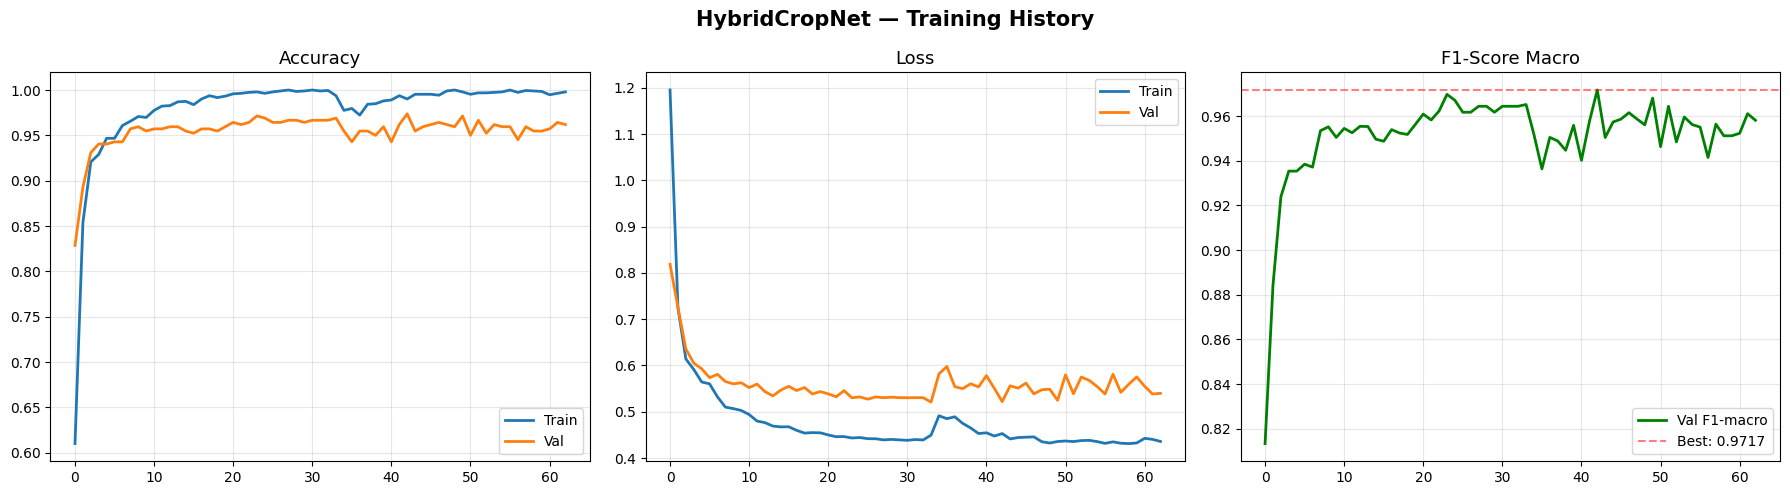

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['accuracy'],     label='Train', lw=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   lw=2)
axes[0].set_title('Accuracy', fontsize=13); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', lw=2)
axes[1].plot(history.history['val_loss'], label='Val',   lw=2)
axes[1].set_title('Loss', fontsize=13); axes[1].legend(); axes[1].grid(alpha=0.3)

if 'val_f1_macro' in history.history:
    axes[2].plot(f1_cb.history_f1, label='Val F1-macro', lw=2, color='green')
    axes[2].axhline(max(f1_cb.history_f1), ls='--', color='red', alpha=0.5,
                    label=f'Best: {max(f1_cb.history_f1):.4f}')
    axes[2].set_title('F1-Score Macro', fontsize=13); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('HybridCropNet — Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150)
plt.show()

# Evaluation sur le Test Set

In [15]:
preds   = model(
    (tf.constant(X_test.astype(np.float32)),
     tf.constant(mask_test),
     tf.constant(S_test)),
    training=False
).numpy()

y_pred  = np.argmax(preds,      axis=1)
y_true  = y_test_enc

print('=' * 65)
print('CLASSIFICATION REPORT — HybridCropNet (Test Set)')
print('=' * 65)
print(classification_report(y_true, y_pred,
                             target_names=class_names_ordered,
                             zero_division=0))

acc         = np.mean(y_true == y_pred)
f1_macro    = f1_score(y_true, y_pred, average='macro',    zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f'Overall Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'F1 Macro          : {f1_macro:.4f}')
print(f'F1 Weighted       : {f1_weighted:.4f}')

CLASSIFICATION REPORT — HybridCropNet (Test Set)
              precision    recall  f1-score   support

        Corn       1.00      0.99      0.99      2103
      Cotton       0.96      1.00      0.98       412
        Rice       0.99      0.99      0.99      3067
    Soybeans       1.00      0.97      0.98      2615
      Grapes       0.87      0.94      0.90       306
      Others       0.85      0.91      0.88       542

    accuracy                           0.98      9045
   macro avg       0.94      0.97      0.95      9045
weighted avg       0.98      0.98      0.98      9045

Overall Accuracy  : 0.9786  (97.86%)
F1 Macro          : 0.9550
F1 Weighted       : 0.9789


# Matrice de confusion

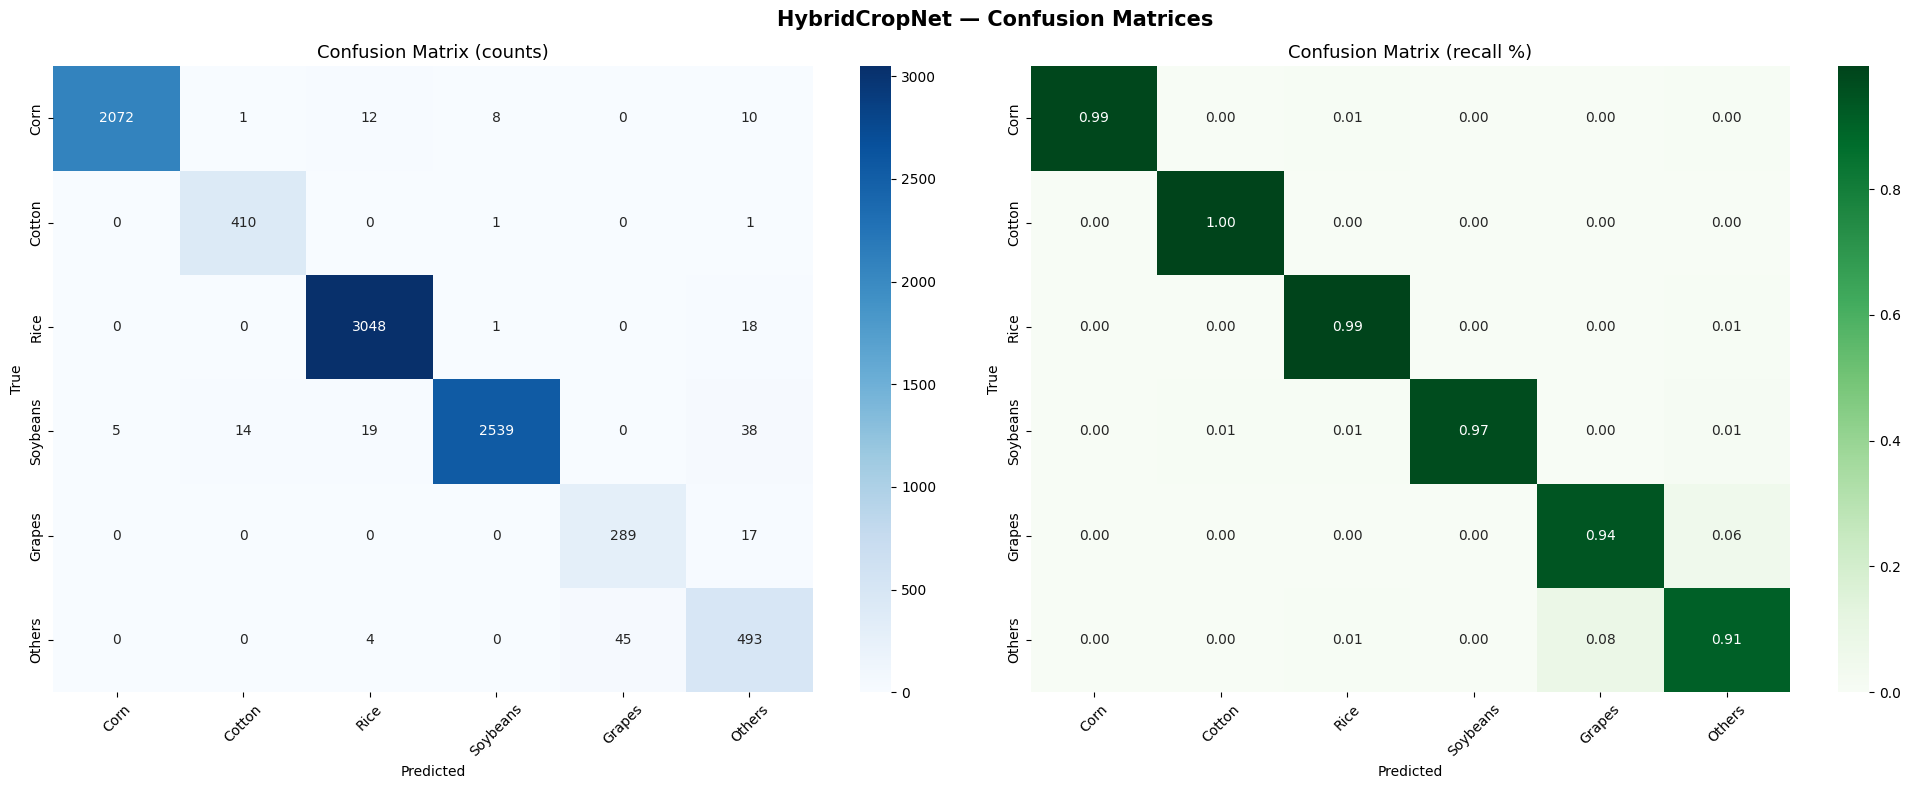

In [16]:
cm = confusion_matrix(y_true, y_pred)

# Normalisation par ligne (recall par classe)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Absolue
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names_ordered, yticklabels=class_names_ordered)
axes[0].set_title('Confusion Matrix (counts)', fontsize=13)
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
axes[0].tick_params(axis='x', rotation=45)

# Normalisée
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=class_names_ordered, yticklabels=class_names_ordered)
axes[1].set_title('Confusion Matrix (recall %)', fontsize=13)
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('HybridCropNet — Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

In [17]:
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score
import numpy as np

# Prédictions
y_pred_proba = model.predict((X_test, mask_test, S_test))
y_pred = np.argmax(y_pred_proba, axis=1)

y_true = y_test

# Métriques
oa = accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')

print("OA:", oa)
print("Kappa:", kappa)
print("Macro F1:", macro_f1)

283/283 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step
OA: 0.9785516860143726
Kappa: 0.9711074038008419
Macro F1: 0.9549852600791828


In [20]:
comparison_results = pd.DataFrame([
    {"Model": "Part 1 - MCTNet", "OA": 0.972, "Kappa": 0.964, "Macro F1": 0.948},
    {"Model": "Part 2 - MCTNet + all covariates", "OA": 0.983, "Kappa": 0.978, "Macro F1": 0.973},
    {"Model": "Part 3 - IncepTAE-CovLF", "OA": globals().get("inceptae_oa", np.nan), "Kappa": globals().get("inceptae_kappa", np.nan), "Macro F1": globals().get("inceptae_macro_f1", np.nan)},
    {"Model": "Part 4 - TSViT", "OA": 0.973, "Kappa": 0.964, "Macro F1": 0.944},
    {"Model": "Part 5 - HybridCropNet", "OA": oa, "Kappa": kappa, "Macro F1": macro_f1}
])
print(comparison_results)

                              Model        OA     Kappa  Macro F1
0                   Part 1 - MCTNet  0.972000  0.964000  0.948000
1  Part 2 - MCTNet + all covariates  0.983000  0.978000  0.973000
2           Part 3 - IncepTAE-CovLF       NaN       NaN       NaN
3                    Part 4 - TSViT  0.973000  0.964000  0.944000
4            Part 5 - HybridCropNet  0.978552  0.971107  0.954985


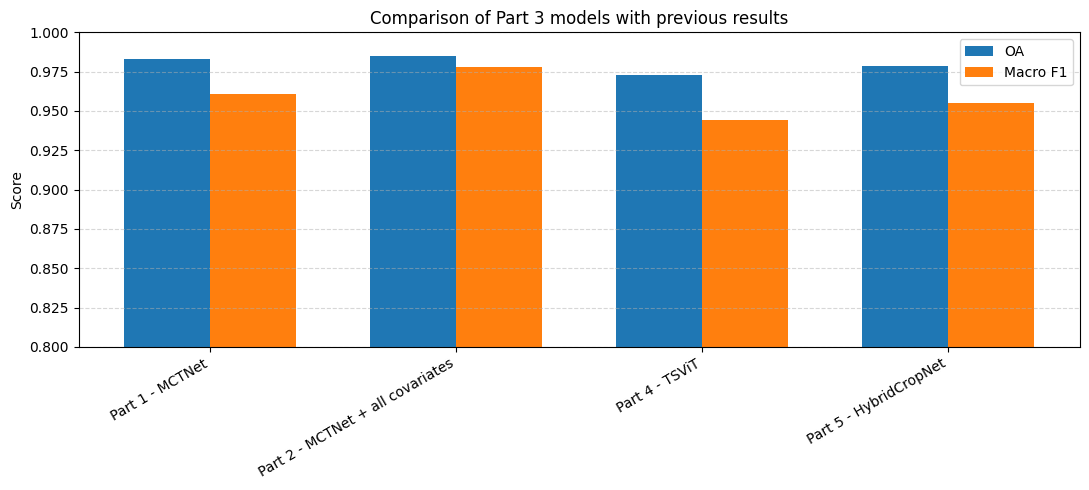

In [19]:
plot_df = comparison_results.dropna(subset=["OA", "Macro F1"]).copy()
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(11, 5))
plt.bar(x - width/2, plot_df["OA"], width, label="OA")
plt.bar(x + width/2, plot_df["Macro F1"], width, label="Macro F1")
plt.xticks(x, plot_df["Model"], rotation=30, ha="right")
plt.ylabel("Score")
plt.title("Comparison of Part 3 models with previous results")
plt.ylim(0.80, 1.0)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# sauvgarde du model

In [ ]:
import pickle

# Sauvegarder le modèle
model.save(os.path.join(SAVE_DIR, 'hybridcropnet_final.keras'))
print('Modèle sauvegardé ')

# Sauvegarder le scaler et le label encoder
with open(os.path.join(SAVE_DIR, 'preprocessing.pkl'), 'wb') as f:
    pickle.dump({
        'scaler'         : scaler,
        'label_encoder'  : label_encoder,
        'region_encoder' : region_enc,
        'feature_cols'   : feature_cols,
        'class_names'    : CLASS_NAMES,
        'num_classes'    : num_classes,
    }, f)
print('Preprocessing sauvegardé ')

print(f'\n Fichiers dans {SAVE_DIR} :')
for f in os.listdir(SAVE_DIR):
    fpath = os.path.join(SAVE_DIR, f)
    size  = os.path.getsize(fpath) / 1024
    print(f'   {f:40s}  {size:8.1f} KB')